In [1]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

import sys
from pathlib import Path

# sys.path.insert(0, str(Path.cwd() / "src"))

from model_alignment_lab.utils.helpers import generate_response, format_example
from model_alignment_lab.evaluation.eval import log_parser, evaluate_tutor_schema_df

from datetime import datetime

ts = datetime.now().strftime("%Y%m%d_%H%M%S")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
## Path Setup
root = Path.cwd()
output_dir = root.parent/"outputs"
datasets_dir = root.parent/"datasets"/"structured_json"
root

PosixPath('/home/derrjohn/git/model-alignment-lab/notebooks')

In [3]:
print(root.is_dir())
print(output_dir.is_dir())
print(datasets_dir.is_dir())

True
True
True


# 1. Base Model Preparation

In [4]:
MODEL_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32
)

model = model.to(device)
model.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 960, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=960, out_features=960, bias=False)
          (k_proj): Linear(in_features=960, out_features=320, bias=False)
          (v_proj): Linear(in_features=960, out_features=320, bias=False)
          (o_proj): Linear(in_features=960, out_features=960, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=960, out_features=2560, bias=False)
          (up_proj): Linear(in_features=960, out_features=2560, bias=False)
          (down_proj): Linear(in_features=2560, out_features=960, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((960,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((960,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((960,), eps=1e-05)
    (r

In [5]:
prompt = """Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A conducting triangular loop is placed near a long straight wire carrying i(t)=I sin(wt). Determine the RMS induced voltage."""

response = generate_response(model, tokenizer, prompt)
print(response)

To find the RMS induced voltage, we need to consider the magnetic field generated by the loop and the current flowing through it. The magnetic field is given by B = μ₀ * I / (2 * π * r), where μ₀ is the magnetic constant (4π × 10^(-7) T m^(-2)), I is the current flowing through the loop, and r is the distance from the wire.

The induced voltage (V) is given by the formula V = -N * (dB/dt), where N is the number of turns in the loop. Since the loop is a triangular shape, we can use the formula for the area of a triangle, which is A = (1/2) * b * h, where b is the base and h is the height.

The area of the triangle is A = (


In [6]:
result = generate_response(
    model,
    tokenizer,
    prompt,
    max_new_tokens=30,
    benchmark=True
)
# print(result["text"])
# print()
print(f"Total Time: {np.round(result['total_time_s'],2)}")
print(f"Generated Tokens: {np.round(result['generated_tokens'],2)}")
print(f"Tokens per second: {np.round(result['tokens_per_second'],2)}")

Total Time: 0.64
Generated Tokens: 30
Tokens per second: 46.71


In [7]:
train_path = datasets_dir.joinpath("TRAIN_em_tutor_chat.jsonl")
test_path = datasets_dir.joinpath("VAL_em_tutor_chat.jsonl")
val_path = datasets_dir.joinpath("TEST_em_tutor_chat.jsonl")

In [8]:
print(train_path.is_file())
print(test_path.is_file())
print(val_path.is_file())

True
True
True


In [9]:
from datasets import load_dataset

train_dataset = load_dataset("json",
                             data_files={
                                 "train": str(train_path)
                             }
                            )["train"]
test_dataset = load_dataset("json",
                            data_files={
                                "test": str(test_path)
                            }
                           )["test"]
val_dataset = load_dataset("json",
                           data_files={
                               "val":str(val_path)
                           }
                          )["val"]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

In [10]:
train_dataset

Dataset({
    features: ['messages'],
    num_rows: 500
})

In [11]:
train_dataset["messages"][0]

[{'role': 'user',
  'content': 'Return ONLY valid JSON.\n\nYou are a helpful personal electromagnetics tutor.\nProvide structured reasoning and educational guidance.\n\nProblem:\nA plane electromagnetic wave propagates in free space. Derive the relationship between E and H fields. Describe the physical interpretation.'},
 {'role': 'assistant',
  'content': '{"problem_type": "electromagnetic_waves", "difficulty": "advanced", "required_concepts": ["Maxwell equations", "wave impedance", "phasors"], "reasoning_path": ["apply curl equations", "solve propagation relation", "derive impedance relation"], "common_mistakes": ["incorrect phase convention", "mixing phasor and time domains"], "prerequisites": ["vector calculus", "curl operator"]}'}]

In [12]:
train_dataset = train_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})
val_dataset = val_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})
test_dataset = test_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [13]:
train_dataset

Dataset({
    features: ['messages', 'text'],
    num_rows: 500
})

In [14]:
print(train_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A plane electromagnetic wave propagates in free space. Derive the relationship between E and H fields. Describe the physical interpretation.<|im_end|>
<|im_start|>assistant
{"problem_type": "electromagnetic_waves", "difficulty": "advanced", "required_concepts": ["Maxwell equations", "wave impedance", "phasors"], "reasoning_path": ["apply curl equations", "solve propagation relation", "derive impedance relation"], "common_mistakes": ["incorrect phase convention", "mixing phasor and time domains"], "prerequisites": ["vector calculus", "curl operator"]}<|im_end|>



# 2. LoRA Finetune 

### LoRA Setup

In [15]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj"]
)


In [16]:
model = get_peft_model(model, peft_config).to(model.device)
model.train()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [17]:
model.print_trainable_parameters()

trainable params: 1,638,400 || all params: 363,459,520 || trainable%: 0.4508


## Training

In [18]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir=str(output_dir/"smollm-em-tutor-lora"),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    dataset_text_field="text",
    use_cpu=False,
    bf16=False,
    fp16=False,
)

In [19]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

Tokenizing train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

In [20]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.224274,0.190940
2,0.037628,0.039344
3,0.032780,0.031962


TrainOutput(global_step=375, training_loss=0.41213186117013295, metrics={'train_runtime': 285.0448, 'train_samples_per_second': 5.262, 'train_steps_per_second': 1.316, 'total_flos': 496491357657600.0, 'train_loss': 0.41213186117013295})

In [21]:
model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [22]:
final_path = str(output_dir/"smollm-em-tutor-lora")
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_v1")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_v1")

('/home/derrjohn/git/model-alignment-lab/outputs/smollm-em-tutor-lora/20260512_210503_final_adapter_v1/tokenizer_config.json',
 '/home/derrjohn/git/model-alignment-lab/outputs/smollm-em-tutor-lora/20260512_210503_final_adapter_v1/chat_template.jinja',
 '/home/derrjohn/git/model-alignment-lab/outputs/smollm-em-tutor-lora/20260512_210503_final_adapter_v1/tokenizer.json')

## Model Evaluation

In [23]:
trainer.state.log_history

[{'loss': 2.9822561264038088,
  'grad_norm': 0.43242838978767395,
  'learning_rate': 0.00019786666666666666,
  'entropy': 1.9830857753753661,
  'num_tokens': 3430.0,
  'mean_token_accuracy': 0.4922835543751717,
  'epoch': 0.04,
  'step': 5},
 {'loss': 2.713427925109863,
  'grad_norm': 0.42540180683135986,
  'learning_rate': 0.0001952,
  'entropy': 2.007892769575119,
  'num_tokens': 6940.0,
  'mean_token_accuracy': 0.5139766544103622,
  'epoch': 0.08,
  'step': 10},
 {'loss': 2.5146902084350584,
  'grad_norm': 0.42781105637550354,
  'learning_rate': 0.00019253333333333334,
  'entropy': 2.0797219932079316,
  'num_tokens': 10403.0,
  'mean_token_accuracy': 0.5418417081236839,
  'epoch': 0.12,
  'step': 15},
 {'loss': 2.3952653884887694,
  'grad_norm': 0.44538038969039917,
  'learning_rate': 0.00018986666666666668,
  'entropy': 2.1458380579948426,
  'num_tokens': 13870.0,
  'mean_token_accuracy': 0.5625621408224106,
  'epoch': 0.16,
  'step': 20},
 {'loss': 2.187940979003906,
  'grad_norm'

In [24]:
train_epochs, train_losses, eval_epochs, eval_losses = log_parser(trainer)

print(train_epochs)
print(train_losses)
print(eval_epochs)
print(eval_losses)

[0.04, 0.08, 0.12, 0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68, 0.72, 0.76, 0.8, 0.84, 0.88, 0.92, 0.96, 1.0, 1.04, 1.08, 1.12, 1.16, 1.2, 1.24, 1.28, 1.32, 1.3599999999999999, 1.4, 1.44, 1.48, 1.52, 1.56, 1.6, 1.6400000000000001, 1.6800000000000002, 1.72, 1.76, 1.8, 1.8399999999999999, 1.88, 1.92, 1.96, 2.0, 2.04, 2.08, 2.12, 2.16, 2.2, 2.24, 2.2800000000000002, 2.32, 2.36, 2.4, 2.44, 2.48, 2.52, 2.56, 2.6, 2.64, 2.68, 2.7199999999999998, 2.76, 2.8, 2.84, 2.88, 2.92, 2.96, 3.0]
[2.9822561264038088, 2.713427925109863, 2.5146902084350584, 2.3952653884887694, 2.187940979003906, 1.9605297088623046, 1.763148880004883, 1.507596206665039, 1.3271224975585938, 1.1280168533325194, 0.9128545761108399, 0.8041694641113282, 0.7027249336242676, 0.6899488925933838, 0.6632899761199951, 0.5812224388122559, 0.5661790847778321, 0.48042869567871094, 0.46778016090393065, 0.408800745010376, 0.34488606452941895, 0.35037596225738527, 0.31147279739379885, 0.2525413751602173,

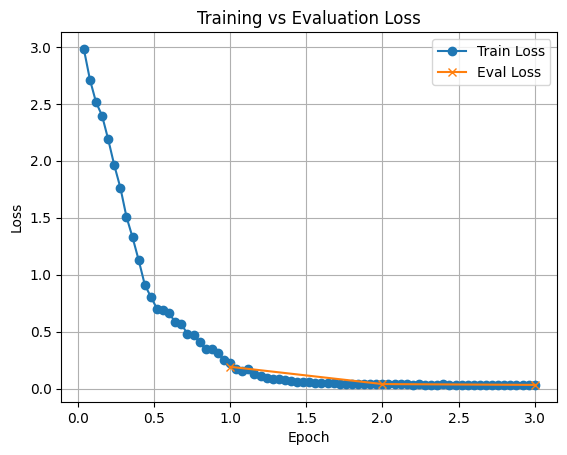

In [25]:
figure, ax = plt.subplots()

ax.plot(train_epochs, train_losses, marker="o", label="Train Loss")
ax.plot(eval_epochs, eval_losses, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [26]:
prompt

'Return ONLY valid JSON.\n\nYou are a helpful personal electromagnetics tutor.\nProvide structured reasoning and educational guidance.\n\nProblem:\nA conducting triangular loop is placed near a long straight wire carrying i(t)=I sin(wt). Determine the RMS induced voltage.'

In [27]:
response = generate_response(model, tokenizer, prompt)
print(response)

{"problem_type": "magnetic_induction", "difficulty": "advanced", "required_concepts": ["Faraday law", "magnetic flux", "time varying fields"], "reasoning_path": ["compute magnetic field", "integrate flux", "differentiate with respect to time"], "common_mistakes": ["incorrect flux integration", "missing negative sign"], "prerequisites": ["integration", "magnetostatics"]}


In [28]:
print(test_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A plane electromagnetic wave propagates in free space. Derive the relationship between E and H fields. Identify common conceptual pitfalls.<|im_end|>
<|im_start|>assistant
{"problem_type": "electromagnetic_waves", "difficulty": "advanced", "required_concepts": ["Maxwell equations", "wave impedance", "phasors"], "reasoning_path": ["apply curl equations", "solve propagation relation", "derive impedance relation"], "common_mistakes": ["incorrect phase convention", "mixing phasor and time domains"], "prerequisites": ["vector calculus", "curl operator"]}<|im_end|>



In [29]:
df = evaluate_tutor_schema_df(model, tokenizer, test_dataset)
df.head()

,prompt,valid_json,pred_problem_type,actual_problem_type,problem_type_match,pred_difficulty,actual_difficulty,difficulty_match,pred_required_concepts,actual_required_concepts,...,equations_match,pred_final_answer,actual_final_answer,final_answer_match,pred_common_mistakes,actual_common_mistakes,mistakes_match,overall_match,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nYou are a helpful p...,True,electromagnetic_waves,electromagnetic_waves,True,advanced,advanced,True,"[Maxwell equations, wave impedance, phasors]","[Maxwell equations, wave impedance, phasors]",...,True,None,None,True,"[incorrect phase convention, mixing phasor and...","[incorrect phase convention, mixing phasor and...",True,True,"{""problem_type"": ""electromagnetic_waves"", ""dif...","{""problem_type"": ""electromagnetic_waves"", ""dif..."
1,Return ONLY valid JSON.\n\nYou are a helpful p...,True,electromagnetic_waves,electromagnetic_waves,True,advanced,advanced,True,"[Maxwell equations, wave impedance, phasors]","[Maxwell equations, wave impedance, phasors]",...,True,None,None,True,"[incorrect phase convention, mixing phasor and...","[incorrect phase convention, mixing phasor and...",True,True,"{""problem_type"": ""electromagnetic_waves"", ""dif...","{""problem_type"": ""electromagnetic_waves"", ""dif..."
2,Return ONLY valid JSON.\n\nYou are a helpful p...,True,magnetostatics,magnetostatics,True,beginner,beginner,True,"[Ampere law, cylindrical symmetry]","[Ampere law, cylindrical symmetry]",...,True,None,None,True,"[incorrect radial distance, wrong symmetry ass...","[incorrect radial distance, wrong symmetry ass...",True,True,"{""problem_type"": ""magnetostatics"", ""difficulty...","{""problem_type"": ""magnetostatics"", ""difficulty..."
3,Return ONLY valid JSON.\n\nYou are a helpful p...,True,student_support,student_support,True,beginner,beginner,True,"[wave propagation, time varying fields]","[wave propagation, time varying fields]",...,True,None,None,True,"[assuming instantaneous propagation, confusing...","[assuming instantaneous propagation, confusing...",True,True,"{""problem_type"": ""student_support"", ""difficult...","{""problem_type"": ""student_support"", ""difficult..."
4,Return ONLY valid JSON.\n\nYou are a helpful p...,True,magnetostatics,magnetostatics,True,beginner,beginner,True,"[Ampere law, cylindrical symmetry]","[Ampere law, cylindrical symmetry]",...,True,None,None,True,"[incorrect radial distance, wrong symmetry ass...","[incorrect radial distance, wrong symmetry ass...",True,True,"{""problem_type"": ""magnetostatics"", ""difficulty...","{""problem_type"": ""magnetostatics"", ""difficulty..."


In [30]:
df.problem_type_match.value_counts()

problem_type_match
True    100
Name: count, dtype: int64

In [31]:
df.difficulty_match.value_counts()

difficulty_match
True    100
Name: count, dtype: int64

In [32]:
df.final_answer_match.value_counts()

final_answer_match
True    100
Name: count, dtype: int64

## Train mas

In [33]:
# Increase number of epochs
trainer.args.num_train_epochs = 6
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.027568,0.029248
2,0.025148,0.027411
3,0.026452,0.026125
4,0.023799,0.024295
5,0.023177,0.023685
6,0.023535,0.023589


TrainOutput(global_step=750, training_loss=0.02598190995057424, metrics={'train_runtime': 603.0156, 'train_samples_per_second': 4.975, 'train_steps_per_second': 1.244, 'total_flos': 992982715315200.0, 'train_loss': 0.02598190995057424})

## Model v2 Eval

In [34]:
train_epochs, train_losses, eval_epochs, eval_losses = log_parser(trainer)

print(train_epochs)
print(train_losses)
print(eval_epochs)
print(eval_losses)

[0.04, 0.08, 0.12, 0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68, 0.72, 0.76, 0.8, 0.84, 0.88, 0.92, 0.96, 1.0, 1.04, 1.08, 1.12, 1.16, 1.2, 1.24, 1.28, 1.32, 1.3599999999999999, 1.4, 1.44, 1.48, 1.52, 1.56, 1.6, 1.6400000000000001, 1.6800000000000002, 1.72, 1.76, 1.8, 1.8399999999999999, 1.88, 1.92, 1.96, 2.0, 2.04, 2.08, 2.12, 2.16, 2.2, 2.24, 2.2800000000000002, 2.32, 2.36, 2.4, 2.44, 2.48, 2.52, 2.56, 2.6, 2.64, 2.68, 2.7199999999999998, 2.76, 2.8, 2.84, 2.88, 2.92, 2.96, 3.0, 3.04, 3.08, 3.12, 3.16, 3.2, 3.24, 3.2800000000000002, 3.32, 3.36, 3.4, 3.44, 3.48, 3.52, 3.56, 3.6, 3.64, 3.68, 3.7199999999999998, 3.76, 3.8, 3.84, 3.88, 3.92, 3.96, 4.0, 4.04, 4.08, 4.12, 4.16, 4.2, 4.24, 4.28, 4.32, 4.36, 4.4, 4.44, 4.48, 4.52, 4.5600000000000005, 4.6, 4.64, 4.68, 4.72, 4.76, 4.8, 4.84, 4.88, 4.92, 4.96, 5.0, 5.04, 5.08, 5.12, 5.16, 5.2, 5.24, 5.28, 5.32, 5.36, 5.4, 5.44, 5.48, 5.52, 5.5600000000000005, 5.6, 5.64, 5.68, 5.72, 5.76, 5.8, 5.84, 5.88, 5.92, 

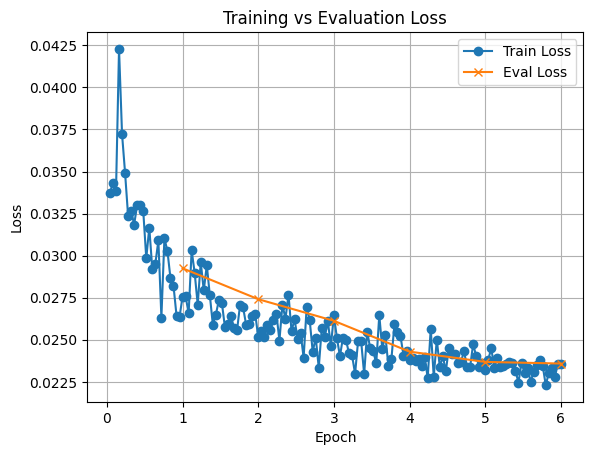

In [35]:
figure, ax = plt.subplots()

ax.plot(train_epochs, train_losses, marker="o", label="Train Loss")
ax.plot(eval_epochs, eval_losses, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [36]:
prompt 

'Return ONLY valid JSON.\n\nYou are a helpful personal electromagnetics tutor.\nProvide structured reasoning and educational guidance.\n\nProblem:\nA conducting triangular loop is placed near a long straight wire carrying i(t)=I sin(wt). Determine the RMS induced voltage.'

In [37]:
generate_response(model, tokenizer, prompt)

'{"problem_type": "magnetic_induction", "difficulty": "advanced", "required_concepts": ["Faraday law", "magnetic flux", "time varying fields"], "reasoning_path": ["compute magnetic field", "integrate flux", "differentiate with respect to time"], "common_mistakes": ["incorrect flux integration", "missing negative sign"], "prerequisites": ["integration", "magnetostatics"]}'

In [38]:
df_2 = evaluate_tutor_schema_df(model, tokenizer, test_dataset)
df_2.head()

,prompt,valid_json,pred_problem_type,actual_problem_type,problem_type_match,pred_difficulty,actual_difficulty,difficulty_match,pred_required_concepts,actual_required_concepts,...,equations_match,pred_final_answer,actual_final_answer,final_answer_match,pred_common_mistakes,actual_common_mistakes,mistakes_match,overall_match,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nYou are a helpful p...,True,electromagnetic_waves,electromagnetic_waves,True,advanced,advanced,True,"[Maxwell equations, wave impedance, phasors]","[Maxwell equations, wave impedance, phasors]",...,True,None,None,True,"[incorrect phase convention, mixing phasor and...","[incorrect phase convention, mixing phasor and...",True,True,"{""problem_type"": ""electromagnetic_waves"", ""dif...","{""problem_type"": ""electromagnetic_waves"", ""dif..."
1,Return ONLY valid JSON.\n\nYou are a helpful p...,True,electromagnetic_waves,electromagnetic_waves,True,advanced,advanced,True,"[Maxwell equations, wave impedance, phasors]","[Maxwell equations, wave impedance, phasors]",...,True,None,None,True,"[incorrect phase convention, mixing phasor and...","[incorrect phase convention, mixing phasor and...",True,True,"{""problem_type"": ""electromagnetic_waves"", ""dif...","{""problem_type"": ""electromagnetic_waves"", ""dif..."
2,Return ONLY valid JSON.\n\nYou are a helpful p...,True,magnetostatics,magnetostatics,True,beginner,beginner,True,"[Ampere law, cylindrical symmetry]","[Ampere law, cylindrical symmetry]",...,True,None,None,True,"[incorrect radial distance, wrong symmetry ass...","[incorrect radial distance, wrong symmetry ass...",True,True,"{""problem_type"": ""magnetostatics"", ""difficulty...","{""problem_type"": ""magnetostatics"", ""difficulty..."
3,Return ONLY valid JSON.\n\nYou are a helpful p...,True,student_support,student_support,True,beginner,beginner,True,"[wave propagation, time varying fields]","[wave propagation, time varying fields]",...,True,None,None,True,"[assuming instantaneous propagation, confusing...","[assuming instantaneous propagation, confusing...",True,True,"{""problem_type"": ""student_support"", ""difficult...","{""problem_type"": ""student_support"", ""difficult..."
4,Return ONLY valid JSON.\n\nYou are a helpful p...,True,magnetostatics,magnetostatics,True,beginner,beginner,True,"[Ampere law, cylindrical symmetry]","[Ampere law, cylindrical symmetry]",...,True,None,None,True,"[incorrect radial distance, wrong symmetry ass...","[incorrect radial distance, wrong symmetry ass...",True,True,"{""problem_type"": ""magnetostatics"", ""difficulty...","{""problem_type"": ""magnetostatics"", ""difficulty..."


In [39]:
df_2.problem_type_match.value_counts()

problem_type_match
True    100
Name: count, dtype: int64

In [40]:
df_2.difficulty_match.value_counts()

difficulty_match
True    100
Name: count, dtype: int64

In [41]:
df_2.final_answer_match.value_counts()

final_answer_match
True    100
Name: count, dtype: int64

In [42]:
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_v2")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_v2")

('/home/derrjohn/git/model-alignment-lab/outputs/smollm-em-tutor-lora/20260512_210503_final_adapter_v2/tokenizer_config.json',
 '/home/derrjohn/git/model-alignment-lab/outputs/smollm-em-tutor-lora/20260512_210503_final_adapter_v2/chat_template.jinja',
 '/home/derrjohn/git/model-alignment-lab/outputs/smollm-em-tutor-lora/20260512_210503_final_adapter_v2/tokenizer.json')

In [43]:
prompt_2 = """Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
Which problems do I find most difficult?"""


In [44]:
generate_response(model, tokenizer, prompt_2)

'{"problem_type": "meta", "difficulty": "intermediate", "required_concepts": ["amp impedance", "phase relationships"], "reasoning_path": ["explain physical intuition", "solve circuits"], "common_mistakes": ["incorrect phase relationships" or "impedance terms"]}'

In [45]:
structured_output = generate_response(model, tokenizer, prompt_2)
print(structured_output)

{"problem_type": "meta", "difficulty": "intermediate", "required_concepts": ["amp impedance", "phase relationships"], "reasoning_path": ["explain physical intuition", "solve circuits"], "common_mistakes": ["incorrect phase relationships" or "impedance terms"]}


In [46]:
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype="auto",
    device_map="auto"
)
print(base_model)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 960, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=960, out_features=960, bias=False)
          (k_proj): Linear(in_features=960, out_features=320, bias=False)
          (v_proj): Linear(in_features=960, out_features=320, bias=False)
          (o_proj): Linear(in_features=960, out_features=960, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=960, out_features=2560, bias=False)
          (up_proj): Linear(in_features=960, out_features=2560, bias=False)
          (down_proj): Linear(in_features=2560, out_features=960, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((960,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((960,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((960,), eps=1e-05)
    (r

In [47]:
prompt_final = f"""
You are a helpful electromagnetics tutor.

Given the structured analysis below, explain the problem
to a student in a natural educational way.

Structured analysis:
{structured_output}

Tutor explanation:
"""
response = generate_response(base_model, tokenizer, prompt_final, max_new_tokens=500)
print(response)

"This problem is asking you to understand the relationship between the voltage and current in a circuit, specifically in the context of electromagnetic fields. The concept you need to grasp is the idea of impedance, which is a measure of how much a circuit resists the flow of current.

In a circuit, the voltage and current are two sides of the same coin. The voltage represents the push or force that pushes the current through the circuit, while the current represents the flow of electrons. When you have a circuit with a voltage source, it's like a push that pushes the electrons through the circuit.

Now, when you have a circuit with a current source, it's like a flow of electrons that's happening. The current is the actual movement of electrons through the circuit.

The problem is asking you to understand how the voltage and current relate to each other. You need to think about how the voltage is affecting the current, and how the current is affecting the voltage.

To solve this proble

In [48]:
model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [49]:
prompt_3 = """Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A uniformly charged sphere has radius R and charge density ρ. Find the electric field inside and outside the sphere."""

generate_response(model, tokenizer, prompt_3)

'{"problem_type": "electrostatics", "difficulty": "intermediate", "required_concepts": ["Gauss law", "spherical symmetry", "charge enclosure"], "reasoning_path": ["choose Gaussian surface", "compute enclosed charge", "apply Gauss law"], "common_mistakes": ["incorrect enclosed charge", "wrong Gaussian surface"], "prerequisites": ["Coulomb law", "surface integrals"]}'

In [51]:
prompt_4 = """Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A plane electromagnetic wave propagates in free space. Derive the relationship between E and H fields."""

structured_output = generate_response(model, tokenizer, prompt_4)

In [52]:
prompt_final = f"""
You are a helpful electromagnetics tutor.

Given the structured analysis below, explain the problem
to a student in a natural educational way.

Structured analysis:
{structured_output}

Tutor explanation:
"""
response = generate_response(base_model, tokenizer, prompt_final, max_new_tokens=500)
print(response)

"To solve this problem, we need to break it down into smaller, manageable parts. The problem involves understanding Maxwell's equations, wave impedance, phasors, and the propagation relation.

First, we need to apply the curl equations to the given Maxwell equations. Maxwell's equations are a set of four equations that describe the behavior of electromagnetic waves. The curl equations are a way to relate the electric and magnetic fields to each other.

Next, we need to solve the propagation relation, which is a relationship that describes how the electric and magnetic fields change over time. This relation is based on the wave impedance, which is a measure of how fast the electric and magnetic fields can change.

Finally, we need to derive the impedance relation, which is a relationship that describes how the electric and magnetic fields change over time. This relation is based on the wave impedance and the phase convention.

To avoid common mistakes, we need to make sure that we apply